<div dir="rtl" style="text-align: right;">

# هفته ۱۳ — تمرین کلاسی
# از بلوک Transformer تا دسته‌بند حساس به ترتیب


**در این تمرین لازم نیست** مدل متن تولید کند، next-token train شود، یا pretraining انجام دهد.

## سناریو

استارتاپ **مکتب‌پی** می‌خواهد پیام‌های کوتاه انتقال وجه را بفهمد:

- `send fifty from ali to sara` → فرستنده **ali**
- `send fifty from sara to ali` → فرستنده **sara**

کیسهٔ واژه‌ها یکسان است؛ فقط ترتیب عوض شده. Self-attention بدون سیگنال موقعیت این دو جمله را از هم تشخیص نمی‌دهد.

مسیر مدلی که امروز می‌سازید:

```text
token IDs
   ↓
token embeddings + positional encoding
   ↓
[ multi-head self-attention → residual + LayerNorm ]
   ↓
[ feed-forward network     → residual + LayerNorm ]
   ↓
masked pooling
   ↓
فرستنده: ali / sara / nima
```

## هدف جلسه

در پایان باید بتوانید:

1. sinusoidal positional encoding را پیاده کنید و بگویید چرا لازم است.
2. shapeهای Multi-Head Attention را از روی یک مثال واقعی بخوانید.
3. یک Transformer block با residual و LayerNorm و FFN بنویسید.
4. یک encoder کوچک را train کنید و اثر بودن/نبودن موقعیت را اندازه بگیرید.

## زمان‌بندی پیشنهادی

| بخش | موضوع | زمان |
|---|---|---|
| ۰ | داده و padding mask | ۱۵ دقیقه |
| ۱ | Positional encoding | ۲۰ دقیقه |
| ۲ | Multi-head attention و shape | ۲۰ دقیقه |
| ۳ | ساخت Transformer block | ۲۵ دقیقه |
| ۴ | آموزش encoder و آزمایش ترتیب | ۳۵ دقیقه |
| ۵ | جمع‌بندی | ۵ دقیقه |

خانه‌هایی که `# TODO` دارند را شما کامل می‌کنید. بقیهٔ سلول‌ها را اجرا کنید.

پاسخ سؤال‌های متنی را در سلول **پاسخ شما** همان بخش بنویسید.

</div>



<div dir="rtl" style="text-align: right;">

---
# بخش ۰ — داده و batch

داده ساختگی است، اما الگوی آن واقعی است: در پیام‌های مالی، جابه‌جا شدن `from` و `to` معنی را عوض می‌کند.

سه نفر در پیام‌ها ظاهر می‌شوند: `ali`، `sara`، `nima`. برچسب هر جمله **فرستنده** است.

سلول زیر را اجرا کنید.

</div>



In [1]:
%matplotlib inline

import math
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)

NAMES = ["ali", "sara", "nima"]
AMOUNTS = ["ten", "twenty", "fifty", "hundred"]
TEMPLATES = [
    "send {amount} from {src} to {dst}",
    "transfer {amount} from {src} to {dst}",
    "please send {amount} from {src} to {dst} today",
    "{src} sent {dst} {amount}",
    "{src} paid {dst} {amount} already",
    "move {amount} from {src} account to {dst} account",
    "{dst} received {amount} from {src}",
    "pay {dst} from {src} {amount}",
]

label_to_id = {name: i for i, name in enumerate(NAMES)}
id_to_label = {i: name for name, i in label_to_id.items()}


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


def build_examples():
    pairs = [(src, dst) for src in NAMES for dst in NAMES if src != dst]
    examples = []
    for template in TEMPLATES:
        for src, dst in pairs:
            for amount in AMOUNTS:
                text = template.format(amount=amount, src=src, dst=dst)
                examples.append((text, src))
    random.shuffle(examples)
    return examples


all_examples = build_examples()
n_train = int(0.8 * len(all_examples))
train_examples = all_examples[:n_train]
test_examples = all_examples[n_train:]

all_tokens = sorted({
    token
    for text, _ in all_examples
    for token in tokenize(text)
})
vocab = ["<pad>", "<unk>"] + all_tokens
stoi = {token: i for i, token in enumerate(vocab)}
itos = {i: token for token, i in stoi.items()}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]
MAX_LEN = 12
D_MODEL = 32
NUM_HEADS = 4
NUM_LAYERS = 2

print(f"train examples: {len(train_examples)}")
print(f"test examples : {len(test_examples)}")
print(f"vocab size    : {len(vocab)}")
print("train labels  :", Counter(label for _, label in train_examples))
print("test labels   :", Counter(label for _, label in test_examples))
print("sample train  :", train_examples[:5])



train examples: 153
test examples : 39
vocab size    : 22
train labels  : Counter({'ali': 55, 'nima': 50, 'sara': 48})
test labels   : Counter({'sara': 16, 'nima': 14, 'ali': 9})
sample train  : [('move ten from sara account to nima account', 'sara'), ('sara received twenty from nima', 'nima'), ('ali paid nima fifty already', 'ali'), ('transfer ten from sara to ali', 'sara'), ('transfer twenty from ali to nima', 'ali')]


<div dir="rtl" style="text-align: right;">

### مشاهدهٔ کلیدی

دو جملهٔ زیر را ببینید. اگر کلمات را مرتب کنیم، کیسهٔ واژه‌ها یکسان است. هر مدلی که ترتیب را نبیند، باید برای هر دو خروجی یکسان بدهد.

</div>



In [2]:
pair_a = "send fifty from ali to sara"
pair_b = "send fifty from sara to ali"


def token_bag(text):
    return tuple(sorted(tokenize(text)))


print("A:", tokenize(pair_a), "→ sender should be ali")
print("B:", tokenize(pair_b), "→ sender should be sara")
print("same bag of words?", token_bag(pair_a) == token_bag(pair_b))



A: ['send', 'fifty', 'from', 'ali', 'to', 'sara'] → sender should be ali
B: ['send', 'fifty', 'from', 'sara', 'to', 'ali'] → sender should be sara
same bag of words? True


<div dir="rtl" style="text-align: right;">

# تمرین ۰ — Padding mask

جمله‌ها طول یکسان ندارند، پس با `<pad>` هم‌طول می‌شوند. Attention نباید pad را مثل یک کلمهٔ واقعی ببیند.

در PyTorch برای `key_padding_mask`:

`True` یعنی این موقعیت را نادیده بگیر.

تابع را کامل کنید تا `input_ids` و `padding_mask` و `labels` برگردد. سپس shapeها را چاپ کنید.

</div>



In [3]:
def encode_text(text, max_len=MAX_LEN):
    ids = [stoi.get(token, UNK_ID) for token in tokenize(text)]
    ids = ids[:max_len]
    ids += [PAD_ID] * (max_len - len(ids))
    return ids


def make_batch(items):
    input_ids = torch.tensor(
        [encode_text(text) for text, _ in items],
        dtype=torch.long,
    )
    labels = torch.tensor(
        [label_to_id[label] for _, label in items],
        dtype=torch.long,
    )

    # TODO: True must mark PAD positions.
    # hint: input_ids.eq(PAD_ID) or (input_ids == PAD_ID)
    padding_mask = input_ids.eq(PAD_ID)

    return input_ids, padding_mask, labels


demo_ids, demo_mask, demo_y = make_batch(train_examples[:4])
print("input_ids    :", demo_ids.shape)
print("padding_mask :", demo_mask.shape)
print("labels       :", demo_y.shape)
print(demo_ids)
print(demo_mask)



input_ids    : torch.Size([4, 12])
padding_mask : torch.Size([4, 12])
labels       : torch.Size([4])
tensor([[ 8, 17,  6, 14,  2, 18,  9,  2,  0,  0,  0,  0],
        [14, 13, 21,  6,  9,  0,  0,  0,  0,  0,  0,  0],
        [ 3, 10,  9,  5,  4,  0,  0,  0,  0,  0,  0,  0],
        [20, 17,  6, 14, 18,  3,  0,  0,  0,  0,  0,  0]])
tensor([[False, False, False, False, False, False, False, False,  True,  True,
          True,  True],
        [False, False, False, False, False,  True,  True,  True,  True,  True,
          True,  True],
        [False, False, False, False, False,  True,  True,  True,  True,  True,
          True,  True],
        [False, False, False, False, False, False,  True,  True,  True,  True,
          True,  True]])


<div dir="rtl" style="text-align: right;">

### بررسی سریع

تعداد `True`های mask باید با تعداد `PAD_ID` برابر باشد.

</div>



In [4]:
# TODO: یک assert بنویسید که تعداد True در demo_mask با تعداد PAD_ID در demo_ids برابر باشد.
assert demo_mask.sum().item() == (demo_ids == PAD_ID).sum().item(),"Mismatch Sum"


<div dir="rtl" style="text-align: right;">

---
# بخش ۱ — Positional encoding

Self-attention همهٔ موقعیت‌ها را با هم مقایسه می‌کند. بدون سیگنال موقعیت، جابه‌جا کردن توکن‌ها فقط خروجی را به همان ترتیب جابه‌جا می‌کند؛ مدل مفهوم «اول / بعد / آخر» ندارد.

در جلسه این جمع را دیدید:

```text
input representation = token embedding + position encoding
```

و برای sinusoidal encoding:

- بعدهای زوج: `sin`
- بعدهای فرد: `cos`

</div>



<div dir="rtl" style="text-align: right;">

# تمرین ۱ — پیاده‌سازی SinusoidalPositionalEncoding

کلاس زیر را کامل کنید.

راهنمایی:

- `positions` شکل `[max_length, 1]` دارد.
- `rates` برای بعدهای زوج محاسبه می‌شود.
- `encoding[:, 0::2] = sin(positions * rates)`
- `encoding[:, 1::2] = cos(something)`

اگر گیر کردید، به سلول پیاده‌سازی جلسه نگاه کنید؛ بعد بدون کپی کردن از روی حافظه کاملش کنید.

</div>



In [5]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_length=128):
        super().__init__()
        positions = torch.arange(max_length, dtype=torch.float32).unsqueeze(1)
        dimensions = torch.arange(0, d_model, 2, dtype=torch.float32)

        # TODO: rates را مطابق فرمول جلسه بسازید.
        # rates_i = 10000 ** (-2i / d_model)
        # hint: torch.exp(-math.log(10000.0) * dimensions / d_model)
        rates = torch.exp(-math.log(10_000.0)*dimensions/d_model)

        encoding = torch.zeros(max_length, d_model)

        # TODO: بعدهای زوج = sin ، بعدهای فرد = cos
        encoding[:, 0::2] = torch.sin(positions * rates)
        encoding[:, 1::2] = torch.cos(
            positions * rates[:encoding[:, 1::2].shape[1]]
        )

        self.register_buffer("encoding", encoding.unsqueeze(0))

    def forward(self, token_vectors):
        length = token_vectors.size(1)
        return token_vectors + self.encoding[:, :length]


position_layer = SinusoidalPositionalEncoding(d_model=8, max_length=16)
zero_tokens = torch.zeros(1, 5, 8)
with_position = position_layer(zero_tokens)

print("input shape :", zero_tokens.shape)
print("output shape:", with_position.shape)
print("position 0  :", with_position[0, 0])
print("position 1  :", with_position[0, 1])



input shape : torch.Size([1, 5, 8])
output shape: torch.Size([1, 5, 8])
position 0  : tensor([0., 1., 0., 1., 0., 1., 0., 1.])
position 1  : tensor([0.8415, 0.5403, 0.0998, 0.9950, 0.0100, 0.9999, 0.0010, 1.0000])


<div dir="rtl" style="text-align: right;">

### بررسی سریع

برای ورودی صفر، بردار موقعیت صفر باید الگوی `[0, 1, 0, 1, ...]` داشته باشد چون `sin(0)=0` و `cos(0)=1`.

</div>



In [6]:
pe_row0 = with_position[0, 0]
assert torch.allclose(pe_row0[0::2], torch.zeros_like(pe_row0[0::2])), "even dims of position 0 should be 0"
assert torch.allclose(pe_row0[1::2], torch.ones_like(pe_row0[1::2])), "odd dims of position 0 should be 1"
assert not torch.allclose(with_position[0, 0], with_position[0, 1]), "different positions need different signals"
print("positional encoding checks passed")



positional encoding checks passed


<div dir="rtl" style="text-align: right;">

نقشهٔ زیر را اجرا کنید. هر سطر یک موقعیت است. بعضی ستون‌ها سریع تغییر می‌کنند و بعضی آهسته؛ همین امضای عددی موقعیت را می‌سازد.

</div>



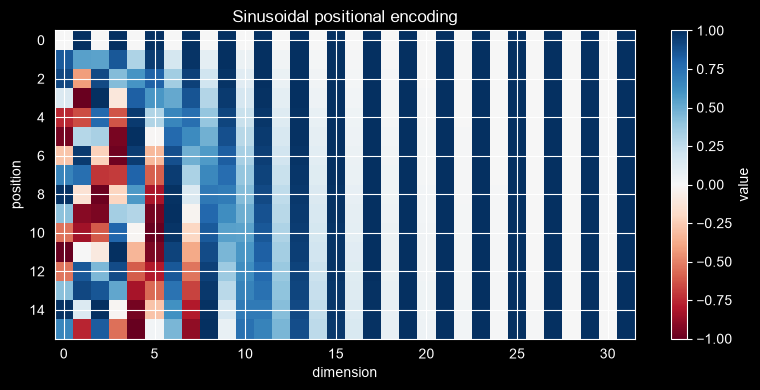

In [7]:
vis_layer = SinusoidalPositionalEncoding(d_model=32, max_length=32)
grid = vis_layer.encoding[0, :16].cpu()

plt.figure(figsize=(8, 4))
plt.imshow(grid, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(label="value")
plt.xlabel("dimension")
plt.ylabel("position")
plt.title("Sinusoidal positional encoding")
plt.tight_layout()
plt.show()



<div dir="rtl" style="text-align: right;">

### سؤال ۱

در دو یا سه جمله پاسخ دهید:

1. چرا بدون positional encoding دو جملهٔ `from ali to sara` و `from sara to ali` برای self-attention + mean pooling یکسان می‌شوند؟
2. sinusoidal encoding چه اطلاعات اضافه‌ای به embedding هر توکن می‌دهد؟

</div>



<div dir="rtl" style="text-align: right;">

**پاسخ شما (سؤال ۱):**

1.در روش self-attention مدل صرفا مفاهیم را استخراج میکند ولی به اطلاعات موقعیت مکانی و توالی توکن ها بی تفاوت است این باعث میشود با عوض شدن محل قرار گیری توکن ها بردار مفهومی استخراج شده اطلاعاتی راجع به ترتیب ها و معانی نهفته در توالی نداشته باشد !

2.ما با تزریق کردن اطلاعات مکانی به امبدینگ توکن ها میتوانیم ترتیب آمدن کلمات و ارتباط آنها در جمله را به مدل بفهمانیم و این چیزی هست که باعث میشود بین from sara to ali و frol ali to sara تفاوت ایجاد شود .

</div>



<div dir="rtl" style="text-align: right;">

---
# بخش ۲ — Multi-head attention و shapeها 

یک head یک فضای Q/K/V یاد می‌گیرد. چند head یعنی چند فضای موازی، بعد concatenate و یک projection نهایی.

برای دادهٔ مکتب‌پی، یک head ممکن است به `from` و نام بعد از آن حساس شود و head دیگر به الگوی `{src} sent {dst}`. لازم نیست نقش هر head را انسان‌پسند فرض کنید؛ مهم این است که shapeها را درست بخوانید.

</div>



<div dir="rtl" style="text-align: right;">

# تمرین ۲ — خواندن shapeها

سلول را کامل کنید:

- `nn.MultiheadAttention` با `d_model=32` و `num_heads=4` و `batch_first=True`
- Self-attention: همان tensor را به‌عنوان Q و K و V بدهید
- `need_weights=True` و `average_attn_weights=False`

سپس این shapeها را چاپ کنید:

- embedding
- خروجی attention
- attention map
- `d_head`

</div>



In [8]:
shape_ids, shape_mask, _ = make_batch(train_examples[:2])
token_embedding = nn.Embedding(len(vocab), D_MODEL, padding_idx=PAD_ID)
embedded = token_embedding(shape_ids)

# TODO: multi-head attention را بسازید و روی embedded اجرا کنید.
multi_head = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=NUM_HEADS, batch_first=True)
# hint: multi_head(embedded, embedded, embedded, key_padding_mask=shape_mask, need_weights=True, average_attn_weights=False)
attended, attention_map = multi_head(

    embedded,embedded,embedded,
    key_padding_mask = shape_mask,
    need_weights=True,
    average_attn_weights=False
)

d_head = D_MODEL // NUM_HEADS

print("input ids        :", shape_ids.shape)
print("embedded         :", embedded.shape)
print("attended         :", attended.shape)
print("attention_map    :", attention_map.shape)
print("d_head           :", d_head)
print("tokens[0]        :", [itos[i.item()] for i in shape_ids[0] if i.item() != PAD_ID])



input ids        : torch.Size([2, 12])
embedded         : torch.Size([2, 12, 32])
attended         : torch.Size([2, 12, 32])
attention_map    : torch.Size([2, 4, 12, 12])
d_head           : 8
tokens[0]        : ['move', 'ten', 'from', 'sara', 'account', 'to', 'nima', 'account']


<div dir="rtl" style="text-align: right;">

### سؤال ۲

با توجه به خروجی سلول قبل پاسخ دهید. اگر `attention_map` شکل
`[batch, heads, query_positions, key_positions]` دارد:

1. مقدار `attention_map[0, 2, 1, 4]` یعنی چه؟ در یک جمله بنویسید.

> بچ صفرم ؛ هد دوم مولتی اتنشن ؛ کوئری اول ؛ بیشترین توجه به کلید چهارم

2. چرا بعدِ Value داخل `attention_map` دیده نمی‌شود؟

> اتنشن مپ ماتریس وزن های اتنشن است که نشان میدهد هر کوئری چه میزان توجهی به هر کلید داشته و Value در این ماتریس نقش ندارد

3. چرا `d_model` باید بر `num_heads` بخش‌پذیر باشد؟

>هر هد مولتی هد اتنشن بخشی مساوی دیگر هد ها ، از بردار امبدینگ توکن مربوطه را پوشش می دهد.
</div>



<div dir="rtl" style="text-align: right;">

**پاسخ شما (سؤال ۲):**

1.
2.
3.

</div>



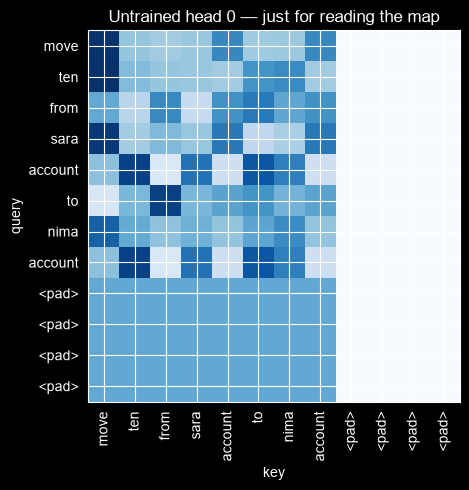

In [9]:
# اگر shape نقشه [batch, heads, query, key] است، یک head را ببینید.
tokens_0 = [itos[i.item()] for i in shape_ids[0]]
head0 = attention_map[0, 0].detach()

plt.figure(figsize=(6, 5))
plt.imshow(head0.numpy(), cmap="Blues")
plt.xticks(range(MAX_LEN), tokens_0, rotation=90)
plt.yticks(range(MAX_LEN), tokens_0)
plt.xlabel("key")
plt.ylabel("query")
plt.title("Untrained head 0 — just for reading the map")
plt.tight_layout()
plt.show()



<div dir="rtl" style="text-align: right;">

---
# بخش ۳ — Residual، LayerNorm و FFN 

در جلسه این الگو را دیدید:

```text
x → sublayer(x) → LayerNorm(x + sublayer(x))
```

و FFN برای هر توکن جدا، با وزن مشترک:

```text
d_model → 4 * d_model → d_model
```

الان این‌ها را داخل یک block واقعی می‌گذارید.

</div>



<div dir="rtl" style="text-align: right;">

# تمرین ۳ — کلاس TransformerBlock

`forward` را کامل کنید:

1. self-attention با `key_padding_mask`
2. residual + LayerNorm
3. feed-forward
4. residual + LayerNorm دوم

خروجی باید همان shape ورودی یعنی `[batch, length, d_model]` را حفظ کند.

</div>



In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            batch_first=True,
        )
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.ReLU(),
            nn.Linear(4 * d_model, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, key_padding_mask=None, attn_mask=None, return_weights=False):
        attn_out, attn_weights = self.mha(
            x, x, x,
            key_padding_mask=key_padding_mask,
            attn_mask=attn_mask,
            need_weights=return_weights,
            average_attn_weights=False,
        )

        # TODO: residual + LayerNorm بعد از attention
        # hint from lecture: LayerNorm(x + sublayer(x))
        after_attn = self.norm1(x + attn_out)

        # TODO: FFN و residual + LayerNorm دوم
        after_ffn = self.norm2(after_attn + self.ffn(after_attn))

        if return_weights:
            return after_ffn, attn_weights
        return after_ffn


block = TransformerBlock(D_MODEL, NUM_HEADS)
block_in = token_embedding(demo_ids)
block_out = block(block_in, key_padding_mask=demo_mask)

print("block input :", block_in.shape)
print("block output:", block_out.shape)
assert block_out.shape == block_in.shape
print("shape preserved")



block input : torch.Size([4, 12, 32])
block output: torch.Size([4, 12, 32])
shape preserved


<div dir="rtl" style="text-align: right;">

### سؤال ۳

1. Residual چه چیزی را برای گرادیان و برای اطلاعات لایهٔ قبل کوتاه می‌کند؟
2. چرا FFN بعد از attention می‌آید، نه به‌جای آن؟ یک جمله کافی است: attention چه می‌کند و FFN چه می‌کند؟
3. LayerNorm روی کدام بعد اعمال می‌شود: batch یا featureهای همان توکن؟

</div>



<div dir="rtl" style="text-align: right;">

**پاسخ شما (سؤال ۳):**

1. مثل شبکه رزنت ، کانکشن های رزیجوآل باعث میشود جریان گرادیان به خوبی  منتقل شود و اگر قرار باشد مدل دچار محو شدگی گرادیان شود به اسکیپ کانکشن جلوی این مسئله گرفته میشود
2. FFN لایه فید فورواردی است که ویژگی های انکود شده متنی را دریافت کرده ! روی آن فیت میشود و دیکود میکند ولی  Attention مسئول انکود کردن ویژگی های توالی دار است برای همین باید قبل از FFN بیاید.
3. بعد فیچر

</div>



<div dir="rtl" style="text-align: right;">

---
# بخش ۴ — Encoder مکتب‌پی

الان قطعه‌ها را روی هم می‌گذارید:

```text
token embedding
 + sinusoidal position
 → TransformerBlock × 2
 → masked mean pooling
 → linear classifier
```

این یک **encoder** است: هر موقعیت می‌تواند به همهٔ موقعیت‌های واقعی جمله نگاه کند.

</div>



<div dir="rtl" style="text-align: right;">

# تمرین ۴A — اسمبل کردن مدل

در `forward` این کارها را انجام دهید:

1. embedding توکن
2. اگر `use_position=True` بود، positional encoding را اضافه کنید
3. `key_padding_mask` را از روی `PAD_ID` بسازید
4. blockها را پشت‌سرهم اجرا کنید
5. pooling از قبل نوشته شده است

</div>



In [11]:
class SenderClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes,
        pad_id,
        d_model=D_MODEL,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        max_length=MAX_LEN,
        use_position=True,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.use_position = use_position

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_encoding = SinusoidalPositionalEncoding(d_model, max_length)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, num_heads) for _ in range(num_layers)]
        )
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, return_weights=False):
        # TODO: embedding
          # self.token_embedding(input_ids)
        x = self.token_embedding(input_ids)

        # TODO: add positional encoding when use_position is True
        if self.use_position:
            # self.position_encoding(x)
            x = self.position_encoding(x)
        # TODO: padding mask, True = ignore
        # input_ids.eq(self.pad_id)
        key_padding_mask = input_ids.eq(self.pad_id)

        attn_weights = None
        for block in self.blocks:
            if return_weights:
                x, attn_weights = block(
                    x,
                    key_padding_mask=key_padding_mask,
                    return_weights=True,
                )
            else:
                x = block(x, key_padding_mask=key_padding_mask)

        valid = input_ids.ne(self.pad_id).unsqueeze(-1)
        sentence_vector = (x * valid).sum(dim=1) / valid.sum(dim=1).clamp_min(1)

        logits = self.classifier(sentence_vector)
        if return_weights:
            return logits, attn_weights
        return logits


train_ids, train_mask, train_y = make_batch(train_examples)
test_ids, test_mask, test_y = make_batch(test_examples)

probe_ids, _, _ = make_batch([(pair_a, "ali"), (pair_b, "sara")])
print("train batch:", train_ids.shape)
print("test batch :", test_ids.shape)



train batch: torch.Size([153, 12])
test batch : torch.Size([39, 12])


<div dir="rtl" style="text-align: right;">

حلقهٔ آموزش آماده است. آن را عوض نکنید؛ فقط مدل‌های مختلف را به آن بدهید.

</div>



In [12]:
def accuracy(model, input_ids, labels):
    model.eval()
    with torch.no_grad():
        pred = model(input_ids).argmax(dim=-1)
    return (pred == labels).float().mean().item()


def predict_senders(model, texts):
    model.eval()
    ids, _, _ = make_batch([(text, NAMES[0]) for text in texts])
    with torch.no_grad():
        pred = model(ids).argmax(dim=-1)
    return [id_to_label[i.item()] for i in pred]


def train_model(use_position=True, epochs=80, seed=SEED):
    torch.manual_seed(seed)
    model = SenderClassifier(
        vocab_size=len(vocab),
        num_classes=len(NAMES),
        pad_id=PAD_ID,
        use_position=use_position,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)
    loss_fn = nn.CrossEntropyLoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(train_ids)
        loss = loss_fn(logits, train_y)
        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch % 20 == 0:
            print(
                f"epoch {epoch:3d} | loss {loss.item():.3f} | "
                f"train {accuracy(model, train_ids, train_y):.2f} | "
                f"test {accuracy(model, test_ids, test_y):.2f}"
            )

    train_acc = accuracy(model, train_ids, train_y)
    test_acc = accuracy(model, test_ids, test_y)
    pair_pred = predict_senders(model, [pair_a, pair_b])
    print(
        f"FINAL | train {train_acc:.2f} | test {test_acc:.2f} | "
        f"{pair_a} → {pair_pred[0]} | {pair_b} → {pair_pred[1]}"
    )
    return model, history



<div dir="rtl" style="text-align: right;">

# تمرین ۴B — آموزش با موقعیت

مدل encoder را **با** positional encoding train کنید. انتظار می‌رود دقت train و test بالا باشد و دو جملهٔ جابه‌جا شده فرستنده‌های متفاوت بگیرند.

</div>



In [13]:
print("=== encoder + positional encoding ===")
model_with_pe, loss_with_pe = train_model(use_position=True)



=== encoder + positional encoding ===


E:\Maktab-145\maktab_kernel\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: The detected GPU (Intel(R) UHD Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://docs.pytorch.org/docs/main/notes/get_start_xpu.html#hardware-prerequisite (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\xpu\XPUFunctions.cpp:134.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch  20 | loss 0.531 | train 0.82 | test 0.67
epoch  40 | loss 0.107 | train 0.99 | test 0.97
epoch  60 | loss 0.003 | train 1.00 | test 1.00
epoch  80 | loss 0.002 | train 1.00 | test 1.00
FINAL | train 1.00 | test 1.00 | send fifty from ali to sara → ali | send fifty from sara to ali → sara


<div dir="rtl" style="text-align: right;">

# تمرین ۴C — همان مدل، بدون موقعیت

حالا `use_position=False`. اگر پیاده‌سازی درست باشد، مدل نباید دو جملهٔ جابه‌جا شده را از هم تفکیک کند.

</div>



In [14]:
print("=== encoder without positional encoding ===")
model_no_pe, loss_no_pe = train_model(use_position=False)



=== encoder without positional encoding ===
epoch  20 | loss 0.691 | train 0.57 | test 0.23
epoch  40 | loss 0.641 | train 0.60 | test 0.10
epoch  60 | loss 0.606 | train 0.60 | test 0.10
epoch  80 | loss 0.579 | train 0.60 | test 0.10
FINAL | train 0.60 | test 0.10 | send fifty from ali to sara → ali | send fifty from sara to ali → ali


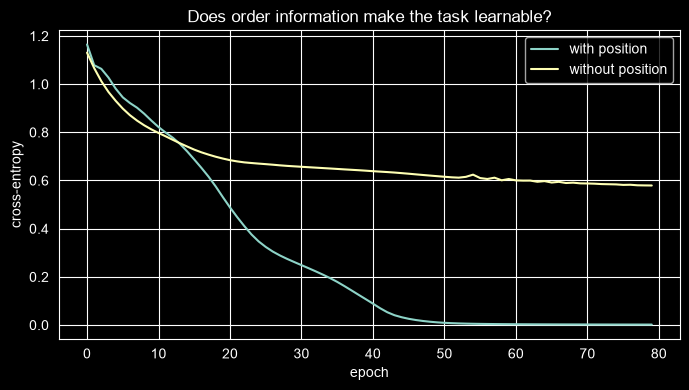

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(loss_with_pe, label="with position")
plt.plot(loss_no_pe, label="without position")
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.title("Does order information make the task learnable?")
plt.legend()
plt.tight_layout()
plt.show()



<div dir="rtl" style="text-align: right;">

بعد از آموزش، attention یک head را روی همان جفت جمله ببینید. دنبال این نیستیم که نقش head «زیبا» باشد؛ فقط ببینید وزن‌ها بعد از یادگیری دیگر یکنواخت نیستند.

</div>



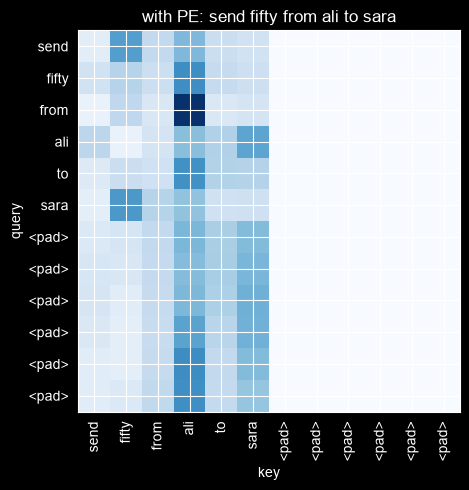

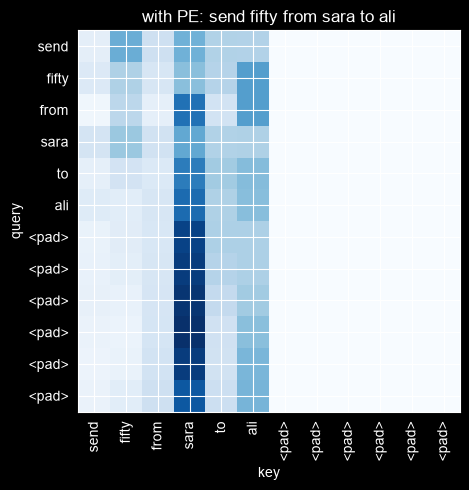

In [16]:
def show_attention(model, text, head=0, title=""):
    ids, _, _ = make_batch([(text, "ali")])
    model.eval()
    with torch.no_grad():
        _, weights = model(ids, return_weights=True)
    tokens = [itos[i.item()] for i in ids[0]]
    mat = weights[0, head].cpu()
    plt.figure(figsize=(6, 5))
    plt.imshow(mat.numpy(), cmap="Blues")
    plt.xticks(range(MAX_LEN), tokens, rotation=90)
    plt.yticks(range(MAX_LEN), tokens)
    plt.xlabel("key")
    plt.ylabel("query")
    plt.title(title or text)
    plt.tight_layout()
    plt.show()


show_attention(model_with_pe, pair_a, head=0, title="with PE: send fifty from ali to sara")
show_attention(model_with_pe, pair_b, head=0, title="with PE: send fifty from sara to ali")



<div dir="rtl" style="text-align: right;">

### سؤال ۴

جدول را با عددهایی که چاپ شد پر کنید:

| مدل | train acc | test acc | پیش‌بینی جمله A | پیش‌بینی جمله B |
|---|-----------|----------|-----------------|-----------------|
| encoder + PE | 100       | 100      | ali             | sara            |
| encoder بدون PE | 60        | 10       | ali             | ali             |

**معیار درست بودن آزمایش:** مدل با PE باید دو جمله را به فرستنده‌های مختلف بدهد. مدل بدون PE معمولاً هر دو را یکسان پیش‌بینی می‌کند، حتی اگر loss کم شود. دقت test بدون PE ممکن است نزدیک شانس (حدود ۰.۳۳) یا حتی بدتر باشد؛ روی این مجموعهٔ کوچک مدل می‌تواند به یک کلاس بچسبد. معیار اصلی همان جفت جمله است.

سپس در دو جمله بگویید: این آزمایش چه چیزی را دربارهٔ Transformer نشان می‌دهد که از روی فرمول به‌تنهایی دیده نمی‌شد؟

</div>



<div dir="rtl" style="text-align: right;">

**پاسخ شما (سؤال ۴):**

جدول:

| مدل | train acc | test acc | پیش‌بینی جمله A | پیش‌بینی جمله B |
|---|-----------|----------|-----------------|-----------------|
| encoder + PE | 100       | 100      | ali             | sara            |
| encoder بدون PE | 60        | 10       | ali             | ali             |

توضیح:
در این مسئله داریم روی یک جمله کار میکنیم ؛ در هنگام کار بر روی جملات توالی اهمیت دارد ، چرا که ذات جمله ارتباط های زنجیره ای به کلمات قبلی آن است ، لذا مدلی که توانسته با پوزیشنال اینفورمیشن این مفاهیم را درک کند توانسته الگو واقعی نهفته در داده را درک کند ولی مدلی که درکی از موقعیت مکانی نداشته دچار مشکل شده و نتوانسته تفاوت فاعل و مفعول را کشف کند
</div>



<div dir="rtl" style="text-align: right;">

---
# بخش ۵ — جمع‌بندی

مسیر امروز:

```text
کلمات → ID
     → embedding + position
     → چند head برای مخلوط کردن اطلاعات توکن‌ها
     → residual + LayerNorm
     → FFN برای تبدیل هر توکن
     → encoder برای طبقه‌بندی کل پیام
```

نتیجهٔ اصلی: بدون positional encoding، دو پیام با کیسهٔ واژهٔ یکسان برای مدل یکی‌اند. با آن، فرستنده قابل تشخیص می‌شود.

</div>

<div dir="rtl" style="text-align: right;">


بدون نگاه کردن به کد، پاسخ کوتاه بدهید:

1. یک Transformer بدون positional encoding چه چیزی را از دست می‌دهد؟ اطلاعات مربوط به توالی توکن ها
2. Multi-head بودن چه چیزی به یک head اضافه می‌کند؟ انعطاف پذیری و تنوع نگرش
3. Residual و FFN هر کدام یک کار مشخص انجام می‌دهند؛ آن دو کار چیست؟ residual  جریان گرادیان را حفظ میکند، FFN دیکود میکند
4. چرا دو جمله با کیسهٔ واژهٔ یکسان، آزمون خوبی برای positional encoding هستند؟ مزیت حقیقی این روش در چنین مسئله هایی مشخص میشود که معنا واقعی تر ترتیب نهفته است.

</div>